<a href="https://colab.research.google.com/github/Ganzo2/Mango-Leaf-Disease-Classification-/blob/main/Mango_Leaf_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")

print("Path to dataset files:", path)


print(os.listdir(path))

100%|██████████| 103M/103M [00:00<00:00, 119MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/mango-leaf-disease-dataset/versions/1
['Gall Midge', 'Die Back', 'Sooty Mould', 'Anthracnose', 'Healthy', 'Bacterial Canker', 'Cutting Weevil', 'Powdery Mildew']


In [ ]:

!pip install -q split-folders

In [ ]:


import splitfolders

splitfolders.ratio(
    path,
    output="dataset",
    seed=42,
    ratio=(0.8, 0.2)
)

Copying files: 4000 files [00:00, 5883.73 files/s]


In [ ]:

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

In [ ]:


IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 8

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

In [ ]:
# ============================================================
# BLOCK 9 — Data Augmentation
# ============================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
# ============================================================
# BLOCK 10 — Load Training Data
# ============================================================

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 3200 images belonging to 8 classes.


In [ ]:
# ============================================================
# BLOCK 11 — Load Validation Data
# ============================================================

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 800 images belonging to 8 classes.


In [ ]:
# ============================================================
# BLOCK 12 — Load ResNet50
# ============================================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ============================================================
# BLOCK 13 — Build Model
# ============================================================

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
# ============================================================
# BLOCK 14 — Compile Model
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================================================
# BLOCK 15 — Model Summary
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================
# BLOCK 16 — Train Model
# ============================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 67s 483ms/step - accuracy: 0.6844 - loss: 0.9777 - val_accuracy: 0.9625 - val_loss: 0.2323
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 441ms/step - accuracy: 0.9203 - loss: 0.2724 - val_accuracy: 0.9762 - val_loss: 0.1135
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 433ms/step - accuracy: 0.9466 - loss: 0.1699 - val_accuracy: 0.9862 - val_loss: 0.0791
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 443ms/step - accuracy: 0.9725 - loss: 0.1068 - val_accuracy: 0.9887 - val_loss: 0.0553
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 435ms/step - accuracy: 0.9800 - loss: 0.0879 - val_accuracy: 0.9937 - val_loss: 0.0492
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 443ms/step - accuracy: 0.9800 - loss: 0.0750 - val_accuracy: 0.9925 - val_loss: 0.0357
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 432ms/step - accuracy: 0.9853 - loss: 0.0584 - val_accuracy: 0.9912 - val_loss: 0.0346
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 436ms/step - accuracy: 0.9816 - loss: 0

In [ ]:
# ============================================================
# BLOCK 17 — Save Model
# ============================================================

model.save("mango_leaf_resnet50.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


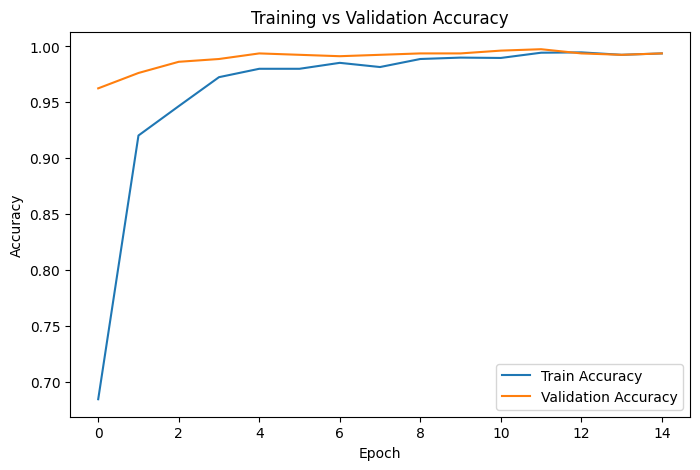

In [ ]:
# ============================================================
# BLOCK 18 — Plot Accuracy
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

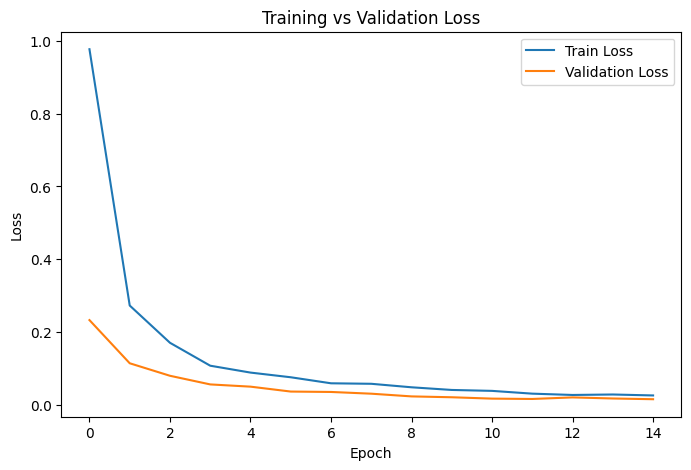

In [ ]:
# ============================================================
# BLOCK 19 — Plot Loss
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
# ============================================================
# BLOCK 20 — Evaluate Model
# ============================================================

loss, acc = model.evaluate(val_generator)

print(f"Validation Accuracy: {acc*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9937 - loss: 0.0146
Validation Accuracy: 99.37%


In [ ]:
# ============================================================
# BLOCK 22 — Import Libraries
# ============================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BLOCK 23 — Generate Predictions
# ============================================================
val_generator.reset()
predictions = model.predict(val_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_generator.classes

class_names = list(val_generator.class_indices.keys())

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step


In [ ]:
# ============================================================
# BLOCK 24 — Create Confusion Matrix
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[100   0   0   0   0   0   0   0]
 [  0 100   0   0   0   0   0   0]
 [  0   0 100   0   0   0   0   0]
 [  0   0   0  99   0   0   1   0]
 [  3   0   0   0  97   0   0   0]
 [  0   0   0   0   0 100   0   0]
 [  0   0   0   0   0   0 100   0]
 [  0   0   0   0   0   0   1  99]]


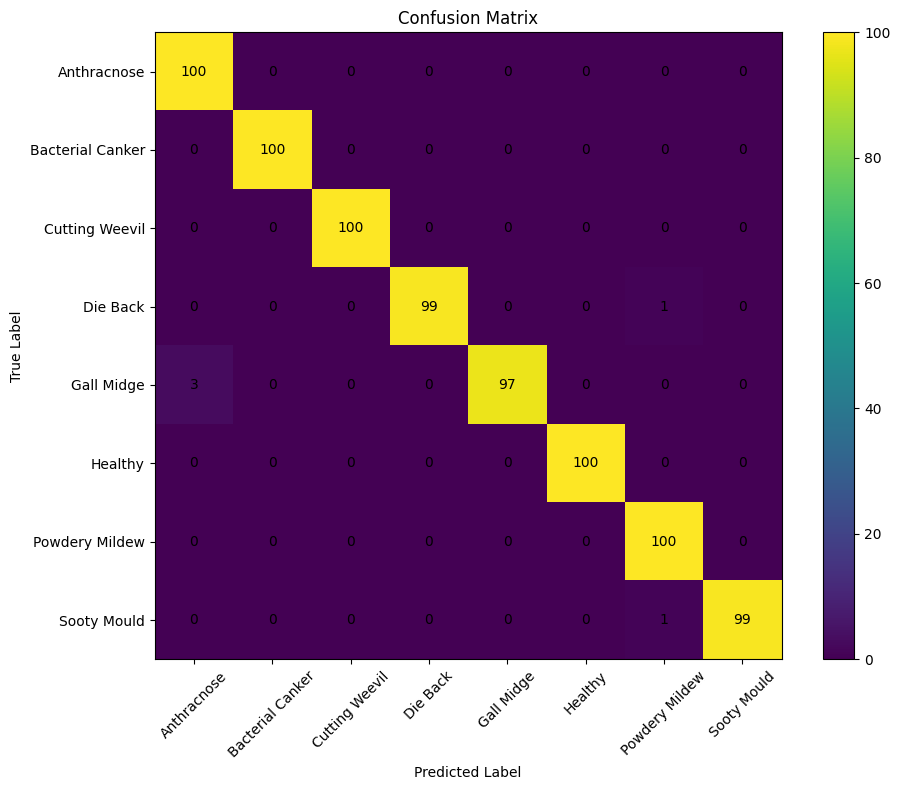

In [ ]:
# ============================================================
# BLOCK 25 — Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)

plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

# Add numbers inside matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()

plt.show()


In [ ]:
# ============================================================
# BLOCK 26 — Classification Report
# ============================================================

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

                  precision    recall  f1-score   support

     Anthracnose       0.97      1.00      0.99       100
Bacterial Canker       1.00      1.00      1.00       100
  Cutting Weevil       1.00      1.00      1.00       100
        Die Back       1.00      0.99      0.99       100
      Gall Midge       1.00      0.97      0.98       100
         Healthy       1.00      1.00      1.00       100
  Powdery Mildew       0.98      1.00      0.99       100
     Sooty Mould       1.00      0.99      0.99       100

        accuracy                           0.99       800
       macro avg       0.99      0.99      0.99       800
    weighted avg       0.99      0.99      0.99       800

